age_scaled                     float64
satisfaction_scaled            float64
client_type_encoded              int64
Country_encoded                  int64
region_encoded                   int64
acquisition_purPose_encoded      int64
referral_channel_encoded         int64
loan_applied_Yes                 int64
dtype: object


,client_id,cluster
0,C0001,3
1,C0002,3
2,C0003,3
3,C0004,3
4,C0005,3
5,C0006,3
6,C0007,3
7,C0008,3
8,C0009,3
9,C0010,3


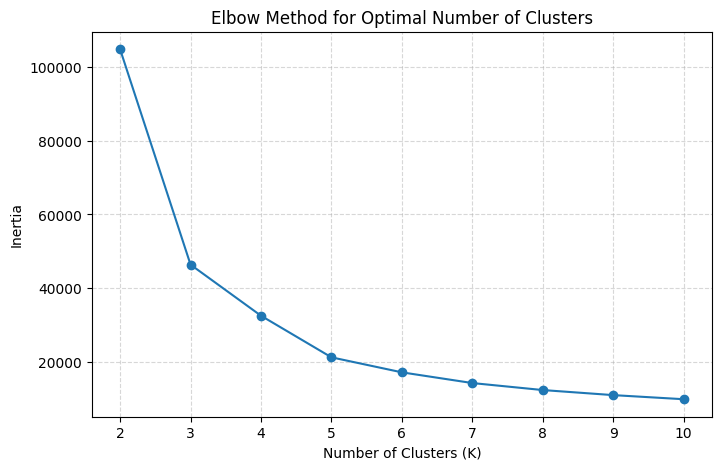

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load the uploaded Excel file using the clients sheet
file_path = "Real_Estate_Market_Intelligent_data.xlsx"
df = pd.read_excel(file_path, sheet_name="clients")

# Define the features to extract
features = [
    'age_scaled',
    'satisfaction_scaled',
    'client_type_encoded',
    'Country_encoded',
    'region_encoded',
    'acquisition_purPose_encoded',
    'loan_applied',
    'referral_channel_encoded'
]

X = df[features]

# Convert any remaining categorical/text values into numeric values
X = pd.get_dummies(X, drop_first=True, dtype=int)

# Check the data
print(X.dtypes)

# K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit the model
kmeans.fit(X)

# Add cluster labels
df['cluster'] = kmeans.labels_

# Display results
display(df[['client_id', 'cluster']].head(10))

inertia = []
k_values = list(range(2, 11))

for k in range(2, 11):
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X)
    inertia.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

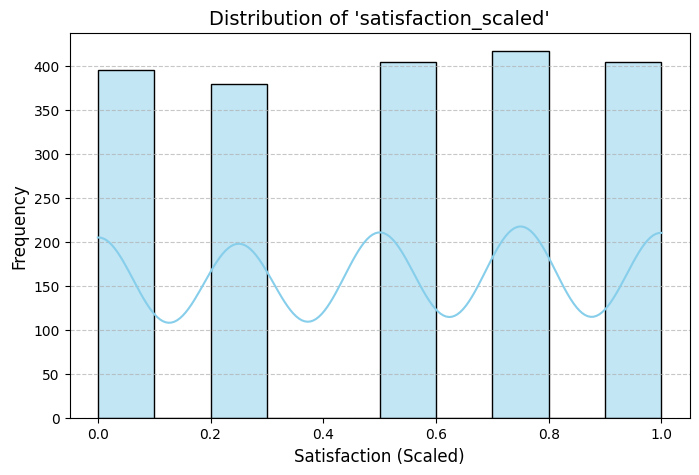

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the histogram of satisfaction_scaled
plt.figure(figsize=(8, 5))
sns.histplot(df['satisfaction_scaled'], bins=10, kde=True, color='skyblue', edgecolor='black')

plt.title("Distribution of 'satisfaction_scaled'", fontsize=14)
plt.xlabel("Satisfaction (Scaled)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

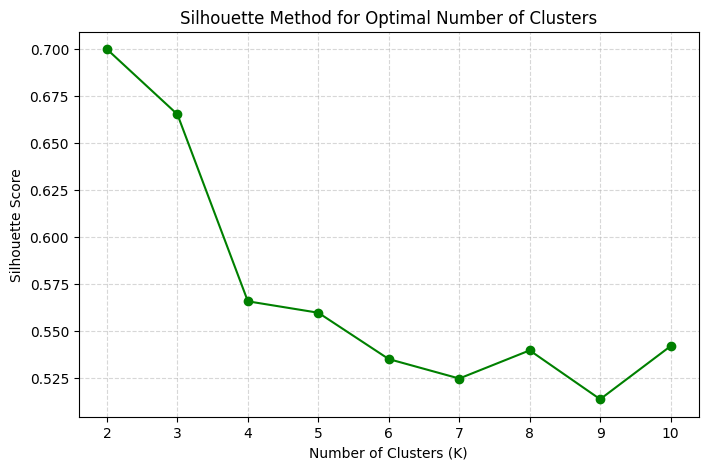

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []
k_values = list(range(2, 11))

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal Number of Clusters')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
import pandas as pd
import os

# Correct path based on system file location
file_path = "/Real_Estate_Market_Intelligent_data.xlsx"

if not os.path.exists(file_path):
    # Fallback to current directory or Google Drive
    if os.path.exists("Real_Estate_Market_Intelligent_data.xlsx"):
        file_path = "Real_Estate_Market_Intelligent_data.xlsx"
    elif os.path.exists("/content/drive/MyDrive/Real_Estate_Market_Intelligent_data.xlsx"):
        file_path = "/content/drive/MyDrive/Real_Estate_Market_Intelligent_data.xlsx"
    else:
        raise FileNotFoundError("Could not locate 'Real_Estate_Market_Intelligent_data.xlsx'. Please ensure it is uploaded.")

df = pd.read_excel(file_path, sheet_name="clients")
df.head()

,client_id,client_type,client_type_encoded,first_name,last_name,date_of_birth,age,age_scaled,gender,country,Country_encoded,region,region_encoded,acquisition_purpose,acquisition_purPose_encoded,satisfaction_score,satisfaction_scaled,loan_applied,referral_channel,referral_channel_encoded
0,C0001,Individual,0,Kareem,Liu,1968-05-11,58,0.471429,F,USA,1,California,1,Home,0,4,0.75,Yes,Website,0
1,C0002,Individual,0,Trystan,Oconnor,1962-11-26,63,0.542857,M,USA,1,California,1,Home,0,1,0.00,No,Website,0
2,C0003,Individual,0,Kale,Gay,1959-04-07,67,0.600000,M,USA,1,California,1,Home,0,4,0.75,Yes,Agency,1
3,C0004,Individual,0,Russell,Gross,1959-11-25,66,0.585714,M,USA,1,California,1,Home,0,5,1.00,No,Website,0
4,C0005,Company,1,Marleez,Co,1976-02-28,50,0.357143,M,USA,1,California,1,Investment,1,5,1.00,No,Website,0


In [ ]:
# check weather cluster column exists
print(df.columns.tolist())

['client_id', 'client_type', 'client_type_encoded', 'first_name', 'last_name', 'date_of_birth', 'age ', 'age_scaled', 'gender', 'country', 'Country_encoded', 'region', 'region_encoded', 'acquisition_purpose', 'acquisition_purPose_encoded', 'satisfaction_score', 'satisfaction_scaled', 'loan_applied', 'referral_channel', 'referral_channel_encoded']


In [ ]:
from sklearn.cluster import KMeans

X = df[['age_scaled']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

df.head()

,client_id,client_type,client_type_encoded,first_name,last_name,date_of_birth,age,age_scaled,gender,country,...,region,region_encoded,acquisition_purpose,acquisition_purPose_encoded,satisfaction_score,satisfaction_scaled,loan_applied,referral_channel,referral_channel_encoded,cluster
0,C0001,Individual,0,Kareem,Liu,1968-05-11,58,0.471429,F,USA,...,California,1,Home,0,4,0.75,Yes,Website,0,0
1,C0002,Individual,0,Trystan,Oconnor,1962-11-26,63,0.542857,M,USA,...,California,1,Home,0,1,0.00,No,Website,0,0
2,C0003,Individual,0,Kale,Gay,1959-04-07,67,0.600000,M,USA,...,California,1,Home,0,4,0.75,Yes,Agency,1,1
3,C0004,Individual,0,Russell,Gross,1959-11-25,66,0.585714,M,USA,...,California,1,Home,0,5,1.00,No,Website,0,1
4,C0005,Company,1,Marleez,Co,1976-02-28,50,0.357143,M,USA,...,California,1,Investment,1,5,1.00,No,Website,0,0


In [ ]:
df['cluster'].value_counts()

,count
cluster,
0,707
1,655
2,638


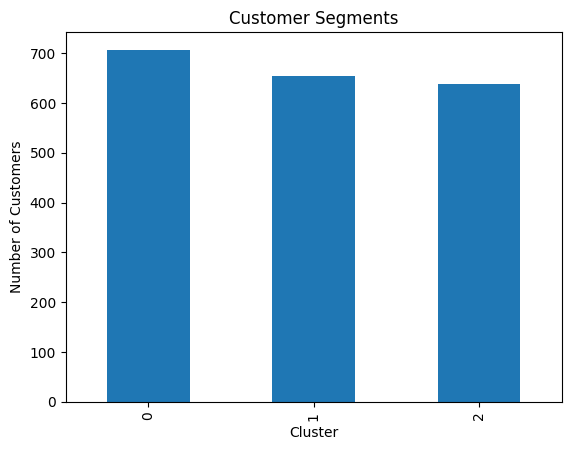

In [ ]:
import matplotlib.pyplot as plt

df['cluster'].value_counts().plot(kind='bar')

plt.title('Customer Segments')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
df.to_csv('final_customer_segmentation.csv', index=False)